In [ ]:
import numpy as np

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv('credit_scoring_model.csv')

In [34]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [35]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [36]:
df.shape

(1000, 11)

In [37]:
df.info

<bound method DataFrame.info of      Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0             0   67    male    2     own             NaN           little   
1             1   22  female    2     own          little         moderate   
2             2   49    male    1     own          little              NaN   
3             3   45    male    2    free          little           little   
4             4   53    male    2    free          little           little   
..          ...  ...     ...  ...     ...             ...              ...   
995         995   31  female    1     own          little              NaN   
996         996   40    male    3     own          little           little   
997         997   38    male    2     own          little              NaN   
998         998   23    male    2    free          little           little   
999         999   27    male    2     own        moderate         moderate   

     Credit amount  Duration              Purpose  Risk  
0             1169         6             radio/TV  good  
1             5951        48             radio/TV   bad  
2             2096        12            education  good  
3             7882        42  furniture/equipment  good  
4             4870        24                  car   bad  
..             ...       ...                  ...   ...  
995           1736        12  furniture/equipment  good  
996           3857        30                  car  good  
997            804        12             radio/TV  good  
998           1845        45             radio/TV   bad  
999           4576        45                  car  good  

[1000 rows x 11 columns]>

In [38]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [39]:
df['Saving accounts'].fillna("unknown", inplace=True)
df['Checking account'].fillna("unknown", inplace=True)

/tmp/ipykernel_14723/152126943.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Saving accounts'].fillna("unknown", inplace=True)
/tmp/ipykernel_14723/152126943.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [40]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


In [41]:
from sklearn.preprocessing import LabelEncoder

In [42]:
le = LabelEncoder()

In [43]:
df["Sex"]=le.fit_transform(df["Sex"])
df["Housing"]=le.fit_transform(df["Housing"])
df["Saving accounts"]=le.fit_transform(df["Saving accounts"])
df["Checking account"]=le.fit_transform(df["Checking account"])
df["Purpose"]=le.fit_transform(df["Purpose"])

In [44]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,1,2,1,4,0,1169,6,5,good
1,1,22,0,2,1,0,1,5951,48,5,bad
2,2,49,1,1,1,0,3,2096,12,3,good
3,3,45,1,2,0,0,0,7882,42,4,good
4,4,53,1,2,0,0,0,4870,24,1,bad


In [45]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [47]:
df["Risk"].value_counts()

,count
Risk,
good,700
bad,300


In [48]:
df["Risk"]=le.fit_transform(df["Risk"])

In [49]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,1,2,1,4,0,1169,6,5,1
1,1,22,0,2,1,0,1,5951,48,5,0
2,2,49,1,1,1,0,3,2096,12,3,1
3,3,45,1,2,0,0,0,7882,42,4,1
4,4,53,1,2,0,0,0,4870,24,1,0


In [53]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

In [54]:
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2, random_state=42)

Logistic regression

In [58]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [59]:
y_pred = model.predict(X_test)

Accuracy Score

In [60]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.76

Classification Report

In [61]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.36      0.47        59
           1       0.78      0.93      0.85       141

    accuracy                           0.76       200
   macro avg       0.73      0.64      0.66       200
weighted avg       0.75      0.76      0.73       200



Random Forest Classifier


In [62]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(accuracy_score(y_test, rf_pred))

0.775


Confusion Matrix


In [63]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[ 21  38]
 [ 10 131]]


ROC_AUC score


In [64]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

np.float64(0.7791801899266738)

In [65]:
RandomForestClassifier(class_weight="balanced")

RandomForestClassifier(class_weight='balanced')

In [66]:
from imblearn.over_sampling import SMOTE


In [67]:
roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

np.float64(0.7791801899266738)

In [68]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.76, 0.775],
    "ROC-AUC": [0.76, 0.779]
})
results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.760,0.760
1,Random Forest,0.775,0.779


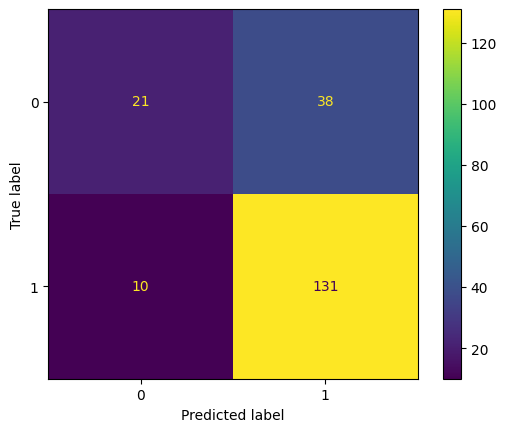

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [70]:
import pickle

pickle.dump(model, open("credit_model.pkl", "wb"))